In [1]:
import pandas as pd
ruta = "/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/PUNTOS/Base de datos/Finales/Compilado.xlsx"

puntos = pd.read_excel(ruta, decimal=",")
puntos.info()
puntos.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   ID        2341 non-null   int64         
 1   Tipo      2341 non-null   object        
 2   Fecha     2341 non-null   datetime64[ns]
 3   Latitud   2341 non-null   float64       
 4   Longitud  2341 non-null   float64       
 5   Sitio     2273 non-null   object        
 6   Fuente    2341 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 128.2+ KB


,ID,Tipo,Fecha,Latitud,Longitud,Sitio,Fuente
0,1,Flujo,1921-01-04,6.194158,-75.570134,*,SIMMA
1,2,Flujo,1921-03-03,6.196886,-75.565530,*,SIMMA
2,3,Flujo,1921-03-13,6.206115,-75.565556,*,SIMMA
3,4,Deslizamiento,1921-10-22,6.250551,-75.595250,*,SIMMA
4,5,Flujo,1923-06-16,6.230405,-75.614995,DE MOLINA,SIMMA


In [2]:
import geopandas as gpd
menm = gpd.GeoDataFrame(puntos,
    geometry=gpd.points_from_xy(puntos.Longitud, puntos.Latitud),
    crs="EPSG:4326")
menm = menm.to_crs("EPSG:9377")

In [3]:

menm["x"] = menm.geometry.x
menm["y"] = menm.geometry.y


print(menm[["Longitud", "Latitud", "x", "y"]].head())


    Longitud   Latitud             x             y
0 -75.570134  6.194158  4.715687e+06  2.243131e+06
1 -75.565530  6.196886  4.716198e+06  2.243431e+06
2 -75.565556  6.206115  4.716200e+06  2.244451e+06
3 -75.595250  6.250551  4.712937e+06  2.249382e+06
4 -75.614995  6.230405  4.710741e+06  2.247165e+06


In [4]:

from pointpats import centrography
import pandas as pd


mprom_cent = centrography.mean_center(menm[['x', 'y']])
med_center = centrography.euclidean_median(menm[['x', 'y']])

In [5]:
!pip install contextily
import seaborn as sbn
import matplotlib.pyplot as plt
import contextily as ctx

#Centrografía

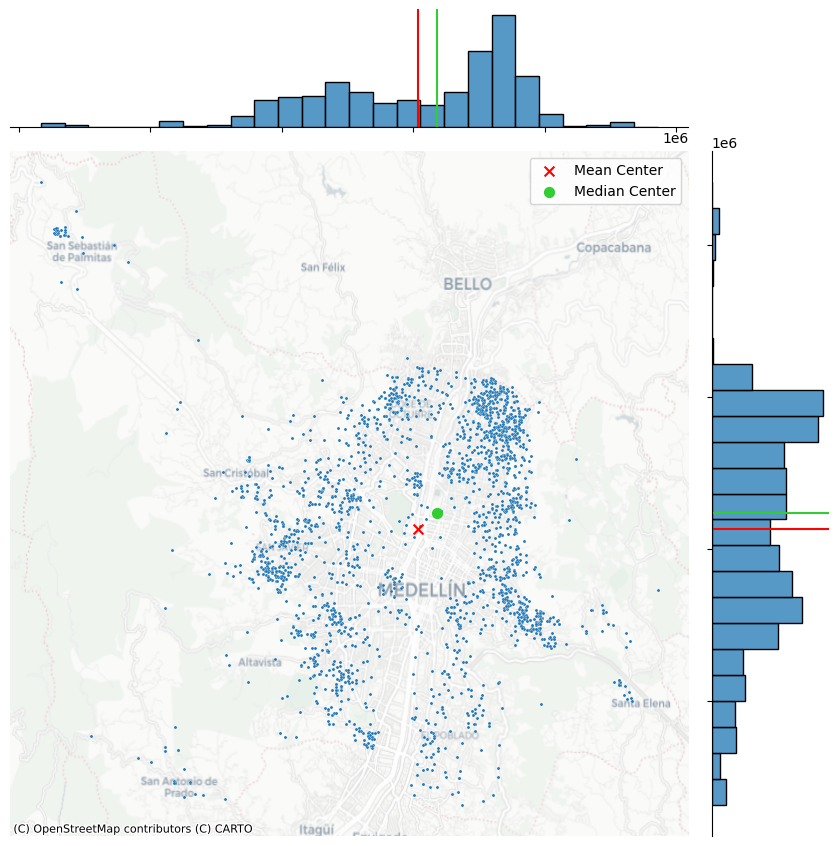

In [6]:
joint_axes = sbn.jointplot(x='x', y='y',data=menm,s=5,height=9)

joint_axes.ax_joint.scatter(*mprom_cent, color='red', marker='x', s=50, label='Mean Center')
joint_axes.ax_marg_x.axvline(mprom_cent[0], color='red')
joint_axes.ax_marg_y.axhline(mprom_cent[1], color='red')

joint_axes.ax_joint.scatter(*med_center, color='limegreen', marker='o', s=50, label='Median Center')
joint_axes.ax_marg_x.axvline(med_center[0], color='limegreen')
joint_axes.ax_marg_y.axhline(med_center[1], color='limegreen')

joint_axes.ax_joint.legend()

ctx.add_basemap(joint_axes.ax_joint,source=ctx.providers.CartoDB.Positron, crs="EPSG:9377")

joint_axes.ax_joint.set_axis_off()

plt.show()

In [7]:
centrography.std_distance(menm[['x', 'y']])

np.float64(5316.191687257342)

#Estadística por cuadrantes

In [8]:
major, minor, rotation = centrography.ellipse(menm[['x', 'y']])

In [9]:
import geopandas as gpd
comuna = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/comunas_med");
comuna = comuna.to_crs("EPSG:9377")


In [10]:
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib.pyplot as plt

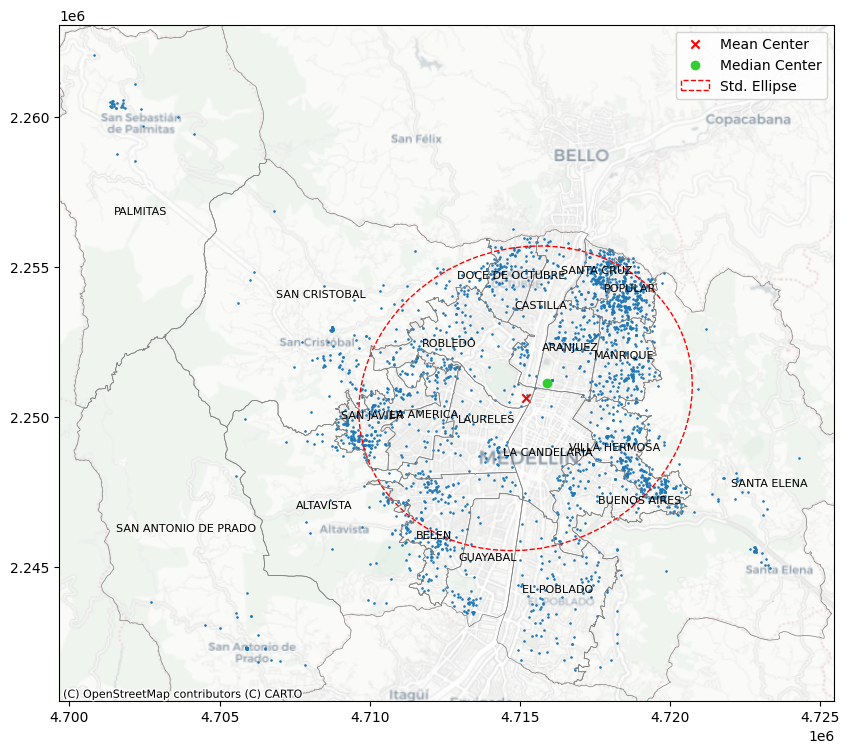

In [11]:
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

ax.scatter(menm['x'], menm['y'], s=0.75,)
ax.scatter(*mprom_cent, color='red', marker='x', label='Mean Center')
ax.scatter(*med_center, color='limegreen', marker='o', label='Median Center')


ellipse = Ellipse(xy=mprom_cent,
                  width=major*2,
                  height=minor*2,
                  angle = np.rad2deg(rotation),
                  facecolor='none',
                  edgecolor='red', linestyle='--',
                  label='Std. Ellipse')
ax.add_patch(ellipse)

ax.legend()

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:9377",
    zorder=0)


comuna.plot(ax=ax, facecolor="none", edgecolor="gray",linewidth=0.5)

comuna["coords"] = comuna.geometry.representative_point()

for idx, row in comuna.iterrows():
    ax.text(
        row["coords"].x,
        row["coords"].y,
        row["NOMBRE"],
        fontsize=8,
        ha='center')
plt.show()

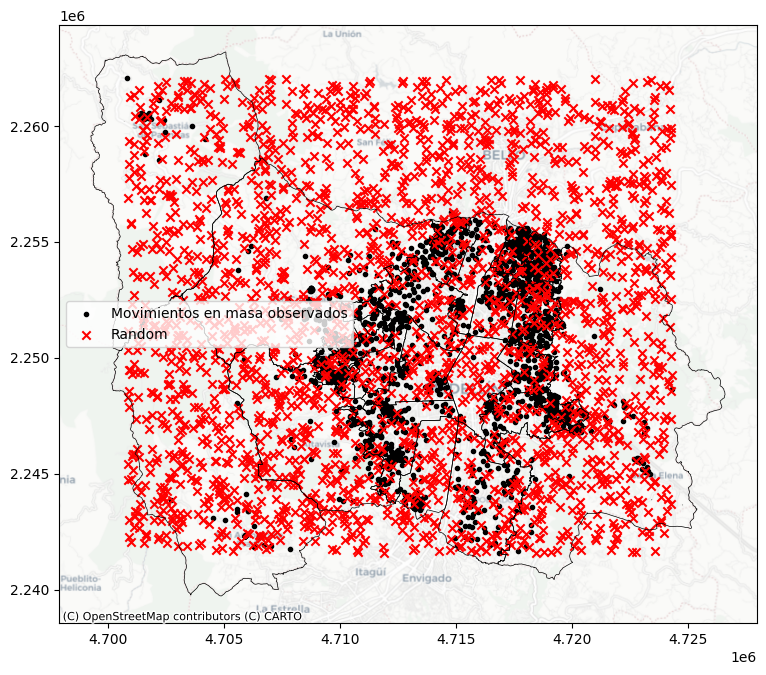

In [12]:
from pointpats import distance_statistics, QStatistic, random, PointPattern
coordenadas = menm[['x', 'y']].values
random_pattern = random.poisson(coordenadas, size=len(coordenadas))

f,ax = plt.subplots(1, figsize=(9, 9))
plt.scatter(*coordenadas.T, color='k', marker='.', label='Movimientos en masa observados')
plt.scatter(*random_pattern.T, color='r', marker='x', label='Random')

comuna.plot(ax=ax, facecolor="none", edgecolor="black",linewidth=0.5)

comuna["coords"] = comuna.geometry.representative_point()

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:9377",
    zorder=0)
ax.legend(ncol=1, loc='center left')
plt.show()

In [13]:
import libpysal
!pip install pointpats

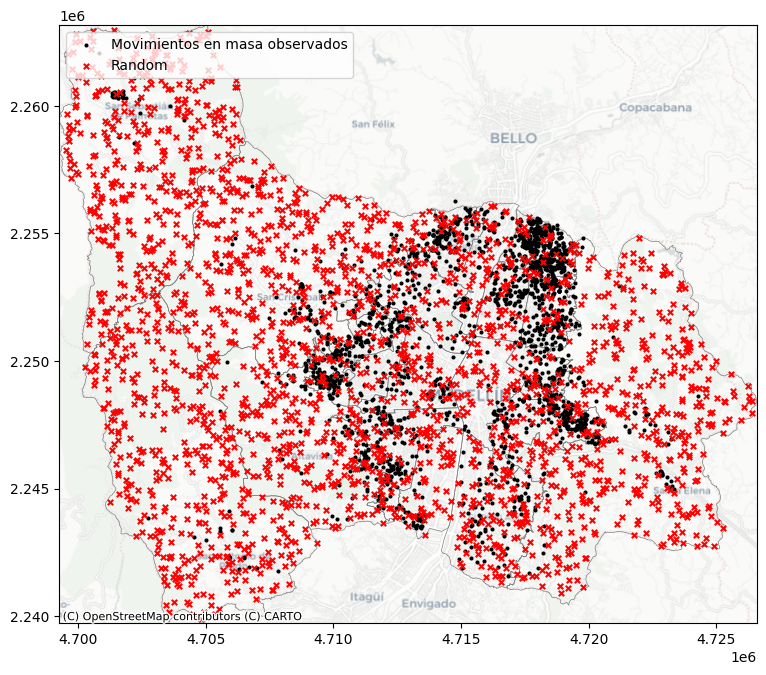

In [14]:
from pointpats import PointPattern
from pointpats.random import poisson


area_estudio = comuna.to_crs(epsg=9377).union_all()

coordenadas_reales = menm.geometry.apply(
    lambda p: (p.x, p.y)).tolist()

coordenadas = np.array(coordenadas_reales)

coordenadas_random = poisson(
    area_estudio, size=(1, len(coordenadas)))


f, ax = plt.subplots(1, figsize=(9, 9))

comuna.plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=0.5, zorder=1)

ax.scatter(
    coordenadas[:, 0], coordenadas[:, 1],
    color="k", marker=".", label="Movimientos en masa observados", s=15,  zorder=2,)

ax.scatter(
    coordenadas_random[:, 0], coordenadas_random[:, 1],
    color="r", marker="x", label="Random", s=15, zorder=3,)


ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs="EPSG:9377", zorder=0)


minx, miny, maxx, maxy = comuna.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.legend(ncol=1, loc="upper left")
plt.show()

np.float64(0.0)

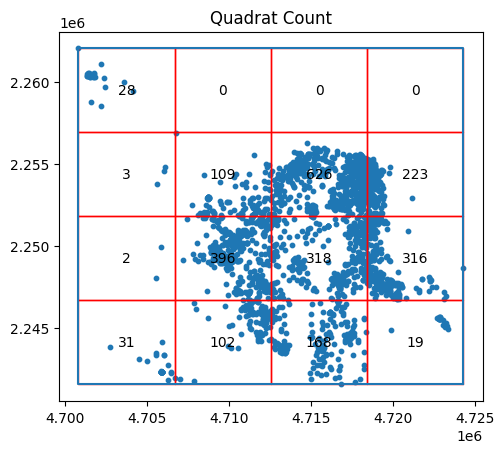

In [15]:
qstat = QStatistic(coordenadas, nx = 4, ny = 4)
qstat.plot()
qstat.chi2_pvalue

#Funciones de Ripley

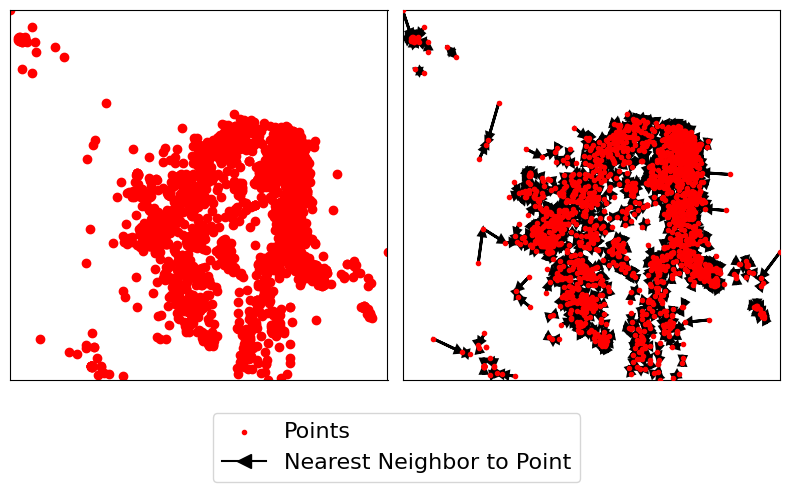

In [16]:
f,ax = plt.subplots(1,2,figsize=(8,4), sharex=True, sharey=True)
ax[0].scatter(*coordenadas.T, color='red')
ax[1].scatter(*coordenadas.T, color='red',
              zorder=100, marker='.', label='Points')

nn_ixs, nn_ds = PointPattern(coordenadas).knn(1)
first = True
for coord, nn_ix, nn_d in zip(coordenadas, nn_ixs, nn_ds):
    dx, dy = coordenadas[nn_ix].squeeze() - coord
    arrow = ax[1].arrow(*coord,
        dx,
        dy,
        length_includes_head=True,
        overhang=0,
        head_length=400,
        head_width=400,
        width=8,
        linewidth=2,
        facecolor='black',
        head_starts_at_zero=False)
    if first:
        plt.plot((1e100, 1e101), (0,1), color='k',
                 marker='<', markersize=10,
                 label='Nearest Neighbor to Point')
    first = False

xmin, ymin = coordenadas.min(axis=0)
xmax, ymax = coordenadas.max(axis=0)

ax[0].axis([xmin, xmax, ymin, ymax])
ax[1].axis([xmin, xmax, ymin, ymax])
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])
ax[0].set_xticks([])
ax[0].set_yticks([])
f.tight_layout()
ax[1].legend(bbox_to_anchor = (.5,-.06), fontsize=16)
plt.show()

##Funcion g

In [17]:
g_test = distance_statistics.g_test(coordenadas, support=40, keep_simulations=True)

In [18]:
print(g_test.support.shape)
print(g_test.simulations.shape)
print(g_test.statistic.shape)
print(g_test.support)


(40,)
(9999, 40)
(40,)
[   0.           55.2682997   110.5365994   165.8048991   221.07319879
  276.34149849  331.60979819  386.87809789  442.14639759  497.41469729
  552.68299698  607.95129668  663.21959638  718.48789608  773.75619578
  829.02449548  884.29279517  939.56109487  994.82939457 1050.09769427
 1105.36599397 1160.63429367 1215.90259336 1271.17089306 1326.43919276
 1381.70749246 1436.97579216 1492.24409186 1547.51239155 1602.78069125
 1658.04899095 1713.31729065 1768.58559035 1823.85389005 1879.12218974
 1934.39048944 1989.65878914 2044.92708884 2100.19538854 2155.46368824]


/tmp/ipykernel_1786/248273333.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


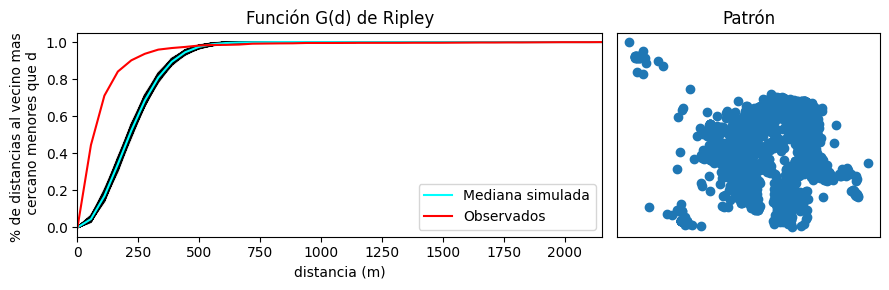

In [19]:
f,ax = plt.subplots(1,2,figsize=(9,3),gridspec_kw=dict(width_ratios=(6,3)))

ax[0].plot(g_test.support, g_test.simulations.T, color='k', alpha=.01)
ax[0].plot(g_test.support, np.median(g_test.simulations, axis=0), color='cyan',label='Mediana simulada')
ax[0].plot(g_test.support, g_test.statistic, label = 'Observados', color='red')

ax[0].set_xlabel('distancia (m)')
ax[0].set_ylabel('% de distancias al vecino mas \n cercano menores que d')
ax[0].legend()
ax[0].set_xlim(
    g_test.support.min(),
    g_test.support.max())

ax[0].set_title('Función G(d) de Ripley')

ax[1].scatter(*coordenadas.T)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].set_title('Patrón')
f.tight_layout()
plt.show()

##Función f

In [20]:
f_test = distance_statistics.f_test(coordenadas, support=40, keep_simulations=True)

/tmp/ipykernel_1786/1020385707.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


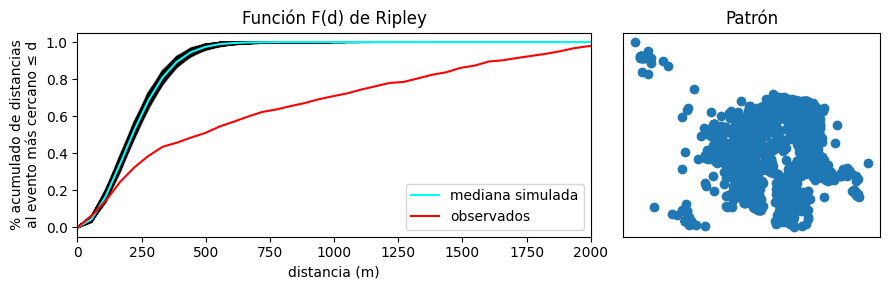

In [21]:
f,ax = plt.subplots(1,2,figsize=(9,3), gridspec_kw=dict(width_ratios=(6,3)))


ax[0].plot(f_test.support, f_test.simulations.T, color='k', alpha=.01)
ax[0].plot(f_test.support, np.median(f_test.simulations, axis=0), color='cyan',label='mediana simulada')


ax[0].plot(f_test.support, f_test.statistic, label = 'observados', color='red')
ax[0].set_xlabel('distancia (m)')
ax[0].set_ylabel('% acumulado de distancias\nal evento más cercano ≤ d')
ax[0].legend()
ax[0].set_xlim(0,2000)
ax[0].set_title('Función F(d) de Ripley')

ax[1].scatter(*coordenadas.T)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].set_title('Patrón')
f.tight_layout()
plt.show()

#DBSCAN

###Análisis de valores para dbscan

##100m

In [22]:
from sklearn.cluster import DBSCAN

clusterer = DBSCAN(eps=400, min_samples=40)

clusterer.fit(menm[["x", "y"]])

DBSCAN(eps=400, min_samples=40)

In [23]:
labels = clusterer.fit_predict(menm[["x", "y"]])
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Número de clústeres:", n_clusters)
print("Puntos clasificados como ruido:", n_noise)
print("Puntos agrupados:", len(labels) - n_noise)

Número de clústeres: 4
Puntos clasificados como ruido: 1530
Puntos agrupados: 811


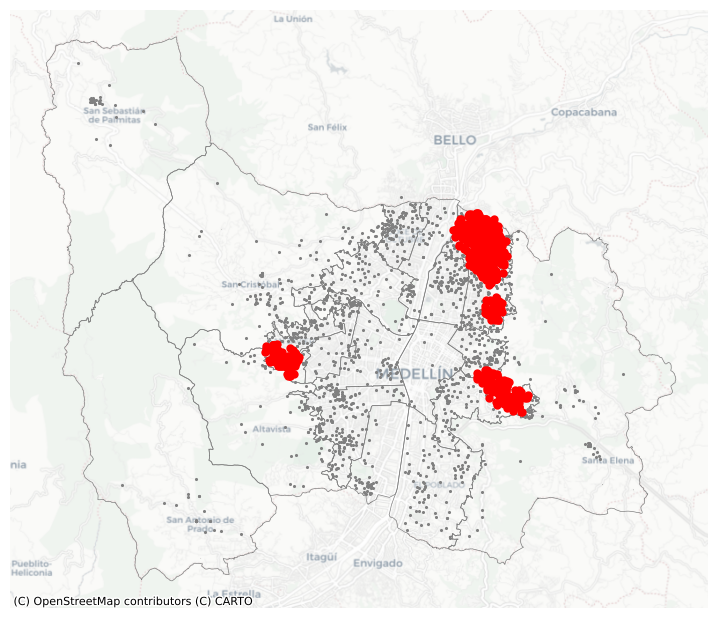

In [24]:
lbls = pd.Series(clusterer.labels_, index=menm.index)

f, ax = plt.subplots(1, figsize=(9, 9))
comuna.plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=0.5, zorder=1)

ruido = menm.loc[lbls==-1, ['x', 'y']]

ax.scatter(ruido['x'], ruido['y'], c='grey', s=5, linewidth=0)
ax.scatter(menm.loc[menm.index.difference(ruido.index), 'x'], \
           menm.loc[menm.index.difference(ruido.index), 'y'], \
          c='red', linewidth=0)
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:9377",
    zorder=0)

ax.set_axis_off()
plt.show()

##200m

In [25]:
clusterer = DBSCAN(eps=200, min_samples=20)

clusterer.fit(menm[["x", "y"]])

DBSCAN(eps=200, min_samples=20)

In [26]:
labels = clusterer.fit_predict(menm[["x", "y"]])
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Número de clústeres:", n_clusters)
print("Puntos clasificados como ruido:", n_noise)
print("Puntos agrupados:", len(labels) - n_noise)

Número de clústeres: 13
Puntos clasificados como ruido: 1814
Puntos agrupados: 527


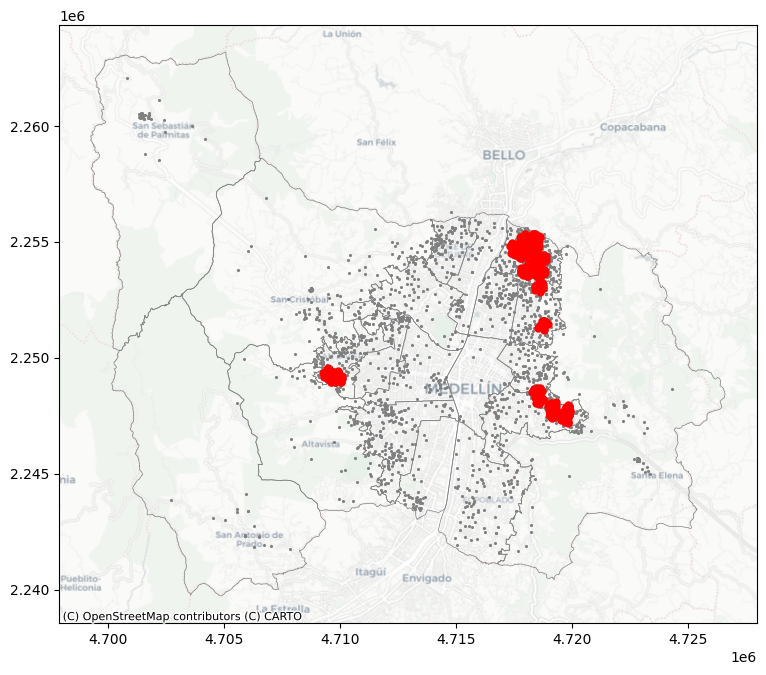

In [27]:
lbls = pd.Series(clusterer.labels_, index=menm.index)

f, ax = plt.subplots(1, figsize=(9, 9))
comuna.plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=0.5, zorder=1)
ruido = menm.loc[lbls==-1, ['x', 'y']]

ax.scatter(ruido['x'], ruido['y'], c='grey', s=5, linewidth=0)
ax.scatter(menm.loc[menm.index.difference(ruido.index), 'x'], \
           menm.loc[menm.index.difference(ruido.index), 'y'], \
          c='red', linewidth=0)
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:9377",
    zorder=0)


plt.show()

##500m

In [28]:
clusterer = DBSCAN(eps=500, min_samples=50)

clusterer.fit(menm[["x", "y"]])

DBSCAN(eps=500, min_samples=50)

In [29]:
labels = clusterer.fit_predict(menm[["x", "y"]])
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Número de clústeres:", n_clusters)
print("Puntos clasificados como ruido:", n_noise)
print("Puntos agrupados:", len(labels) - n_noise)

Número de clústeres: 4
Puntos clasificados como ruido: 1441
Puntos agrupados: 900


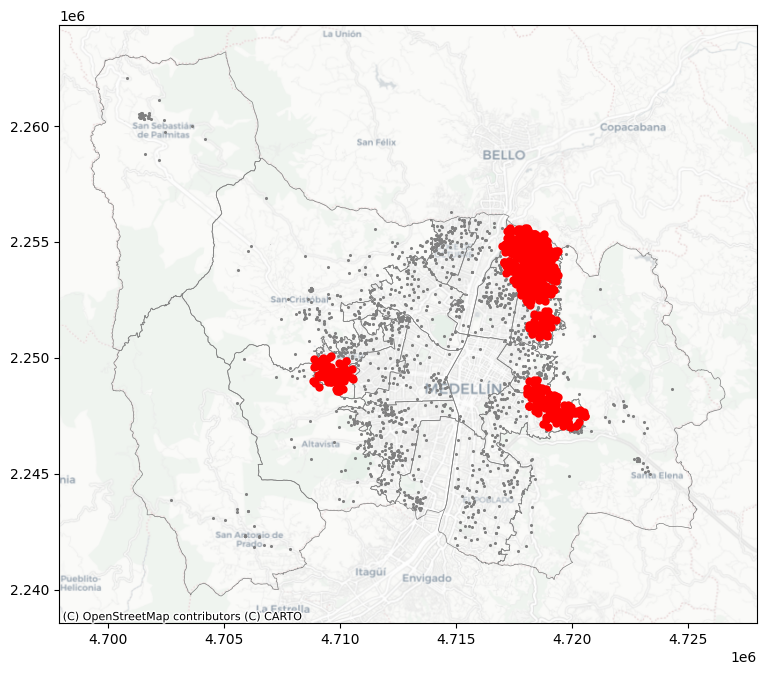

In [30]:
lbls = pd.Series(clusterer.labels_, index=menm.index)

f, ax = plt.subplots(1, figsize=(9, 9))
comuna.plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=0.5, zorder=1)
ruido = menm.loc[lbls==-1, ['x', 'y']]

ax.scatter(ruido['x'], ruido['y'], c='grey', s=5, linewidth=0)
ax.scatter(menm.loc[menm.index.difference(ruido.index), 'x'], \
           menm.loc[menm.index.difference(ruido.index), 'y'], \
          c='red', linewidth=0)
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:9377",
    zorder=0)


plt.show()

In [31]:
eps_values = [100, 150, 200, 300, 400, 500]
min_samples_values = [10, 20, 30, 40, 50]

In [53]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
import pandas as pd
import numpy as np

eps_values = np.arange(0.5, 2.6, 0.25)

min_samples_values = [10,20,30,40,50]
x = menm[["x", "y"]].values
resultados = []

for eps in eps_values:

    for ms in min_samples_values:

        db = DBSCAN(
            eps=eps,
            min_samples=ms)

        clusterer.fit_predict(x)

        ruido = np.sum(labels==-1)
        porcentaje_ruido = 100*ruido/len(labels)

        n_clusters = len(set(labels))- (1 if -1 in labels else 0)

        if n_clusters > 1:

            mask = labels!=-1

            sil = silhouette_score(
                x[mask],
                labels[mask])

        else:

            sil = np.nan

        resultados.append([
            eps,
            ms,
            n_clusters,
            porcentaje_ruido,
            sil
        ])

In [54]:
resultados = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN( eps=eps,  min_samples=ms)
        labels = db.fit_predict(coordenadas)
        mask = labels != -1
        X_valid = coordenadas[mask]
        labels_valid = labels[mask]
        n_clusters = len(set(labels_valid))
        porcentaje_ruido = (1-mask.mean())*100


        if n_clusters > 1:
            sil = silhouette_score(
                X_valid,
                labels_valid)

        else:
            sil = np.nan

        resultados.append([ eps, ms, n_clusters, porcentaje_ruido, sil])

In [55]:
silhouette_df = pd.DataFrame(
    resultados,
    columns=[
        "eps",
        "min_samples",
        "Clusters",
        "%Ruido",
        "Silhouette"])

silhouette_df.sort_values("Silhouette", ascending=False)

,eps,min_samples,Clusters,%Ruido,Silhouette
0,0.50,10,2,98.974797,0.999993
5,0.75,10,2,98.974797,0.999993
10,1.00,10,2,98.974797,0.999993
15,1.25,10,2,98.974797,0.999993
20,1.50,10,2,98.974797,0.999993
25,1.75,10,2,98.974797,0.999993
30,2.00,10,2,98.974797,0.999993
35,2.25,10,2,98.974797,0.999993
40,2.50,10,2,98.974797,0.999993
1,0.50,20,0,100.000000,NaN


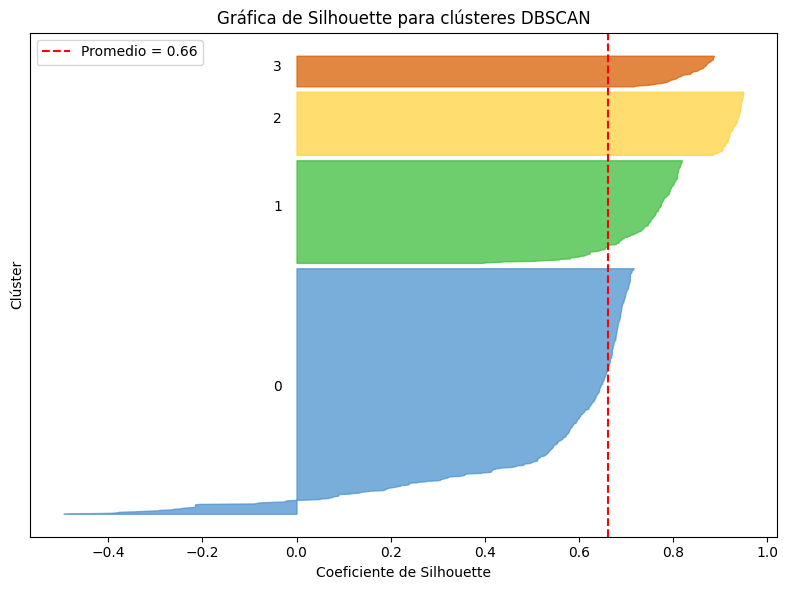

In [56]:
eps = 500
min_samples = 50

colores_cluster = {
     -1: "#B3B3B3",  # Gris claro (ruido)
     0: "#4C93D0",  # Azul
     1: "#3DBE3D",  # Verde
     2: "#FFD23F",  # Amarillo
     3: "#D95F02"}   # Naranja

db = DBSCAN(eps=eps, min_samples=min_samples)

labels = db.fit_predict(coordenadas)
mask = labels != -1
X_sil = coordenadas[mask]
labels_sil = labels[mask]

silhouette_avg = silhouette_score(X_sil, labels_sil)
sample_silhouette_values = silhouette_samples(X_sil, labels_sil)

cluster_labels = np.unique(labels_sil)
n_clusters = len(cluster_labels)

fig, ax = plt.subplots(figsize=(8, 6))

y_lower = 10

for i, cluster in enumerate(cluster_labels):

    ith_cluster_silhouette_values = sample_silhouette_values[labels_sil == cluster]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = colores_cluster.get(cluster, "gray")

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.75)

    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster_i,
        str(cluster))

    y_lower = y_upper + 10

ax.axvline(
    x=silhouette_avg,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Promedio = {silhouette_avg:.2f}")

ax.set_title("Gráfica de Silhouette para clústeres DBSCAN")
ax.set_xlabel("Coeficiente de Silhouette")
ax.set_ylabel("Clúster")

ax.set_yticks([])
ax.legend()

plt.tight_layout()
plt.show()

In [68]:
menm["Cluster"] = labels

In [72]:
menm["Color_cluster"] = ( menm["Cluster"]
    .map(colores_cluster)
    .fillna("gray"))

In [80]:
pip install matplotlib-scalebar

In [81]:
from matplotlib_scalebar.scalebar import ScaleBar

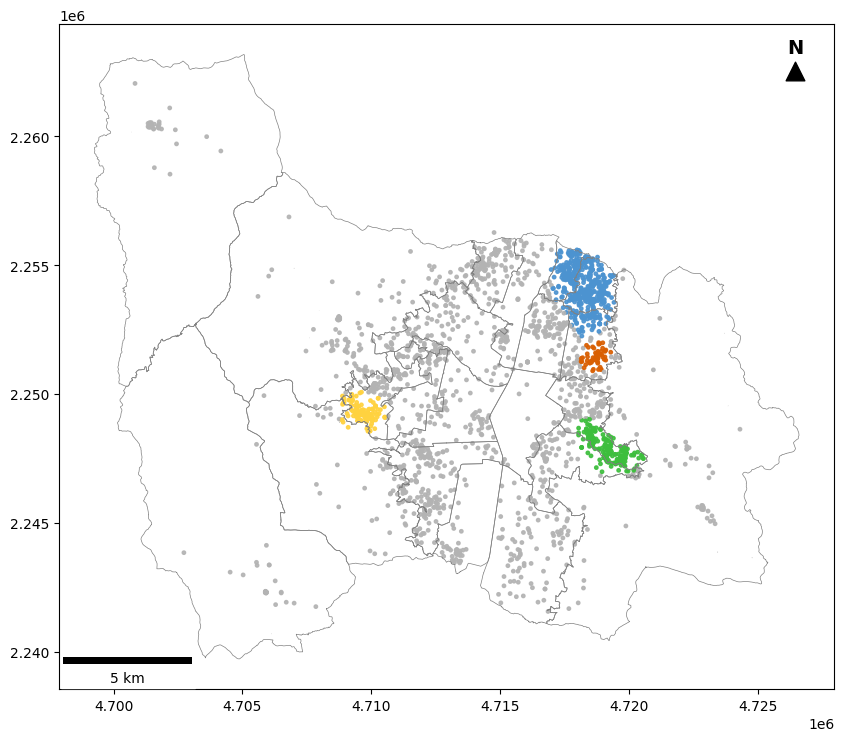

In [82]:
fig, ax = plt.subplots(figsize=(10,10))

comuna.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=0.5)

menm.plot(
    ax=ax,
    color= menm["Color_cluster"],
    markersize=6,
    alpha=0.9)
scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
plt.show()

###Conclusión
Los diferentes métodos de análisis empleados en este notebook para puntos no marcados evidencian que los movimientos en masa registrados en el municipio de Medellín usados para el ejercicio no corresponden a una distribución aleatoria.
La concentración de eventos en las zonas centro y nororiental del municipio sugieren la influencia de factores condicionantes, lo que justifica el análisis de dichos factores en las siguientes etapas del estudio para evaluar la susceptibilidad a movimientos en masa.

#Puntos marcados

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [ ]:
#Comunas de Medellín
comunas = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/menm_m.gpkg", layer="comuna")
comunas.head()

In [ ]:
#Coberturas de Medellín
coberturas = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/menm_m.gpkg", layer="cobertura")
coberturas.head()

In [ ]:
#Geología de Medellín
geologia = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/menm_m.gpkg", layer="geologia")
geologia.head()

In [ ]:
menm_marcado = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/Inventario_Movimientos_Marcado.gpkg")

db = DBSCAN(eps=500,  min_samples=50)

menm_marcado["Cluster"] = db.fit_predict(coordenadas)
menm_marcado.head()

In [ ]:
tabla_geo_cluster = pd.crosstab(
    menm_marcado["Cluster"],
    menm_marcado["SimboloUC"],
    normalize="index") * 100

tabla_geo_cluster = tabla_geo_cluster.round(1)

tabla_geo_cluster

In [ ]:
tabla_cob_cluster = pd.crosstab(
    menm_marcado["Cluster"],
    menm_marcado["Cobertura"],
    normalize="index") * 100

tabla_cob_cluster = tabla_cob_cluster.round(1)

tabla_cob_cluster

In [ ]:
resumen_cluster = (
    menm_marcado
    .groupby("Cluster")
    .agg(
        Eventos=("Cluster", "size"),
        Geologia_dominante=("SimboloUC", lambda x: x.mode().iat[0]),
        Cobertura_dominante=("Cobertura", lambda x: x.mode().iat[0])))
resumen_cluster

In [ ]:
menm_marcado["colores_cluster"] = ( menm_marcado["Cluster"]
    .map(colores_cluster)
    .fillna("gray"))

fig, ax = plt.subplots(figsize=(10, 10))

comunas.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=0.5)

menm_marcado.plot(
    ax=ax,
    color=menm_marcado["colores_cluster"],
    markersize=6,
    alpha=0.9)

for idx, row in comuna.iterrows():
    p = row.geometry.representative_point()

    ax.text(
        p.x,
        p.y,
        row["NOMBRE"].title(),
        fontsize=7,
        ha="center",
        va="center",
        color="black",
        path_effects=[
            pe.withStroke(
                linewidth=2.5,
                foreground="white")])

ax.set_axis_off()

plt.tight_layout()
plt.show()

###Conclusión
Los parámetros de clusterización escogidos para representar mis datos son eps 500 y mas de 50 eventos ya que es la mejor sitribución analizada, todos los clusters tienen un coeficiente de silhouette mayor a la media y presenta el menor porcentaje de puntos no agrupados.
Adicionalmente se observa que todos los clusters se ubican en territorios principalmente artificializados y en geologías de depósitos y dunitas

####Variables categóricas
Se deben pasar a binarias

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
cat = menm_marcado[["SimboloUC", "Cobertura"]]

In [ ]:
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore")

X_cat = encoder.fit_transform(cat)

In [ ]:
X_coord = menm_marcado[["x", "y"]].values

In [ ]:
X = np.hstack( (X_coord, X_cat))
X = StandardScaler().fit_transform(X)